# 05 — Validation & final rankings

Three layers of checking before trusting the numbers:

1. **Data gates** — exact reconciliation of stints against final scores and an
   independent source (notebook 01, re-asserted here).
2. **Reliability** — split-half: fit the model on two disjoint halves of the
   matches and correlate the two sets of ratings. A metric that doesn't
   correlate with itself measures noise.
3. **Face validity & uncertainty** — bootstrap intervals, known-player sniff test.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from plimpact.config import load_config
from plimpact.validate import load_tables

cfg = load_config()
tables = load_tables(cfg)
matches, appearances, shots, stints = (
    tables["matches"], tables["appearances"], tables["shots"], tables["stints"]
)
pd.set_option("display.width", 120)

In [2]:
from plimpact.validate import run_all_checks
failures = run_all_checks(cfg)
assert all(f.empty for f in failures.values())
print("all data gates passed")

all data gates passed


## Split-half reliability

In [3]:
import json
import numpy as np
from plimpact import rapm

design = rapm.build_design(cfg, appearances, stints)
meta = json.load(open(cfg.processed_dir / "model_meta.json"))
players_tbl = pd.read_parquet(cfg.processed_dir / "players.parquet").set_index("player_id")

rows = []
for name, y in (("goals", design.y_goals), ("xg", design.y_xg)):
    halves = rapm.split_half_ratings(design, y, meta[name]["lambda"])
    # correlate only over players with meaningful minutes in the full sample
    keep = players_tbl.loc[halves.index, "total_minutes"] >= cfg.min_minutes
    r = halves[keep.values].corr().iloc[0, 1]
    rows.append({"response": name, "split_half_r": round(r, 3),
                 "players": int(keep.sum())})
pd.DataFrame(rows)

,response,split_half_r,players
0,goals,0.320,589
1,xg,0.326,589


**Honest finding:** with three full seasons, the two responses land close
together (xG edges ahead, but only modestly — its bootstrap signal-to-noise is
~1.36 vs ~1.30 for goals). xG's density advantage matters most in *small*
samples; by ~100 matches per team the goals response has largely caught up.
xG remains the headline metric here for the a-priori reason that it strips
finishing/keeper luck out of the outcome, not because reliability alone forces
the choice. (Raw split-half r understates full-sample reliability since each
half has only half the minutes; Spearman-Brown corrects it:
$r_{full} = 2r/(1+r)$.)

In [4]:
rows_sb = [{"response": r["response"],
            "spearman_brown_r": round(2 * r["split_half_r"] / (1 + r["split_half_r"]), 3)}
           for r in rows]
pd.DataFrame(rows_sb)

,response,spearman_brown_r
0,goals,0.485
1,xg,0.492


## Final rankings with uncertainty

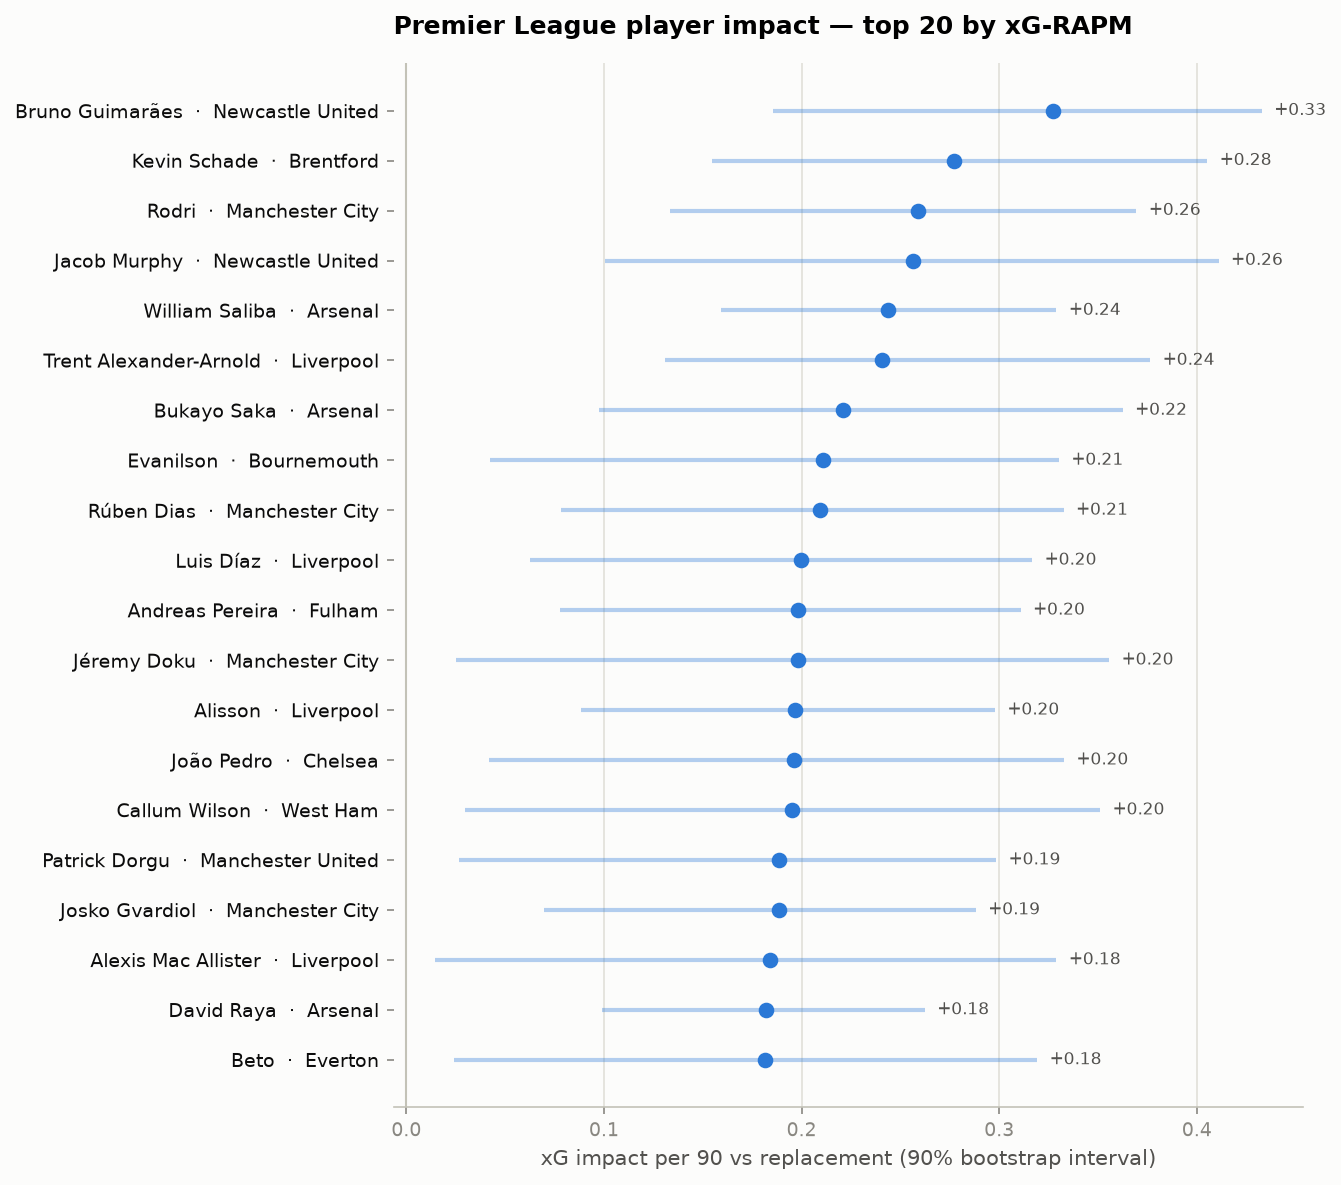

In [5]:
from plimpact.viz import make_outputs
make_outputs(cfg)
from IPython.display import Image
Image(str(cfg.outputs_dir / "top20_xg_rapm.png"), width=820)

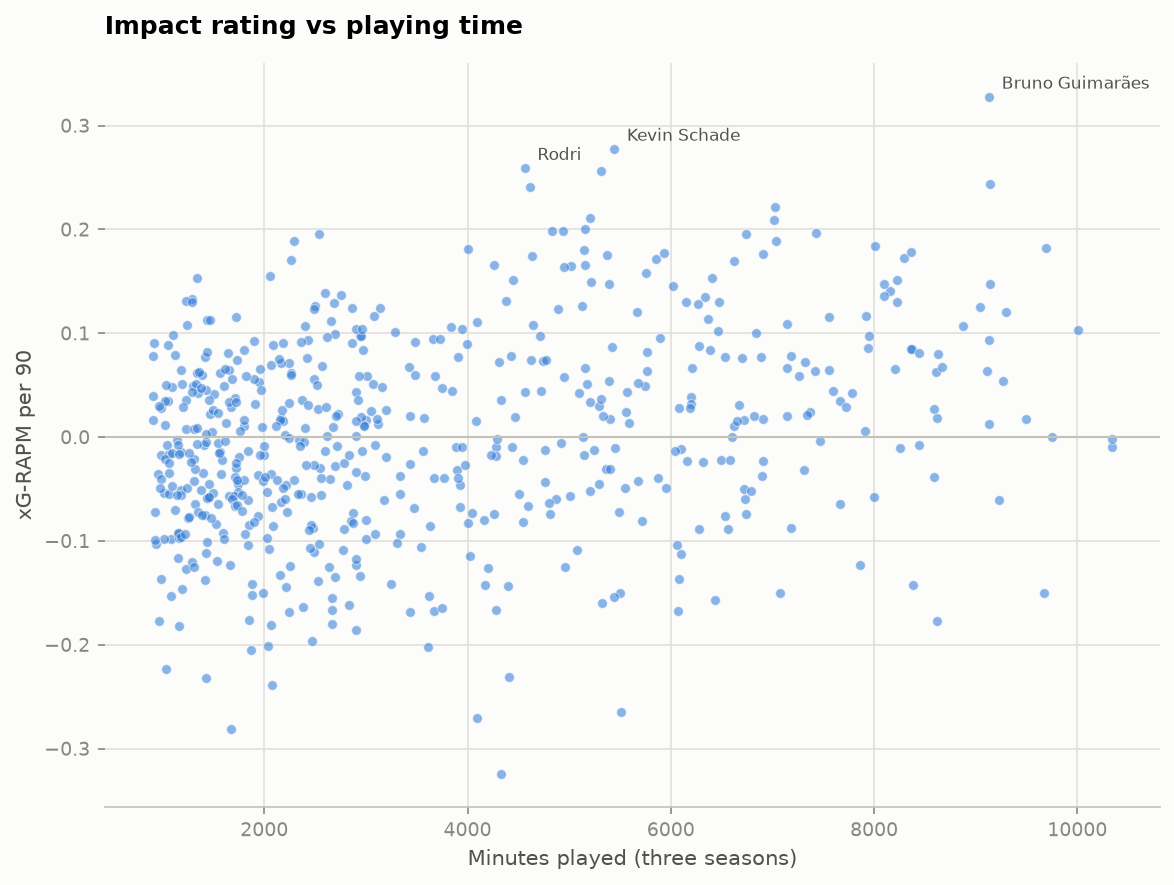

In [6]:
Image(str(cfg.outputs_dir / "rating_vs_minutes.png"), width=760)

In [7]:
ratings = pd.read_parquet(cfg.processed_dir / "ratings.parquet")
cols = ["player", "latest_team", "total_minutes", "rapm_xg", "rapm_xg_lo",
        "rapm_xg_hi", "rapm_goals", "naive_gd90"]
ratings.sort_values("rapm_xg", ascending=False).head(30)[cols].round(3)

,player,latest_team,total_minutes,rapm_xg,rapm_xg_lo,rapm_xg_hi,rapm_goals,naive_gd90
474,Bruno Guimarães,Newcastle United,9133,0.327,0.185,0.433,0.162,1.256
538,Kevin Schade,Brentford,5445,0.277,0.155,0.405,0.139,0.817
239,Rodri,Manchester City,4564,0.259,0.134,0.369,0.235,0.555
312,Jacob Murphy,Newcastle United,5314,0.256,0.101,0.411,0.205,0.781
371,William Saliba,Arsenal,9139,0.244,0.159,0.329,0.259,1.047
225,Trent Alexander-Arnold,Liverpool,4617,0.240,0.131,0.376,0.183,0.822
400,Bukayo Saka,Arsenal,7024,0.221,0.097,0.362,0.136,0.286
170,Evanilson,Bournemouth,5201,0.211,0.043,0.330,-0.017,0.226
521,Rúben Dias,Manchester City,7012,0.209,0.078,0.333,0.182,0.377
23,Luis Díaz,Liverpool,5157,0.200,0.062,0.317,0.220,0.979


## Caveats & future work

- **Bootstrap intervals are wide.** Even three seasons of stints identifies
  individual impact only coarsely — this is honest, and the intervals say so.
- **Substitution non-randomness**: RAPM controls for *who* is on the pitch, not
  *game state*; adding score-state and time-remaining covariates is the natural
  next step.
- **xG is possession-blind**: a model on shot quality won't credit press
  resistance or build-up except through downstream chances (xGChain-weighted
  responses are an extension).
- **Extensions**: player-season splines for aging/form, Bayesian priors from
  market value, opponent-strength interactions, tracking-data covariates.